# Complete Case Analysis (CCA)
Complete Case Analysis, also known as listwise deletion, is a method for handling missing data where only observations (rows) with no missing values in the variables being analyzed are retained, and all rows containing one or more missing values are discarded.

Advantages
- Simple and easy to implement.
- No need to estimate or impute missing values.
- Many statistical software packages perform it automatically.

Disadvantages
- Can substantially reduce the sample size.
- May lead to biased results if the data are not Missing Completely at Random (MCAR).
- Loss of information can reduce statistical power.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [3]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [4]:
df.shape

(19158, 13)

In [6]:
cols = [
    var for var in df.columns
    if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0
]

cols
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [7]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
5882,0.910,no_enrollment,Graduate,5.0,94.0
12570,0.897,no_enrollment,Graduate,11.0,3.0
5318,0.920,no_enrollment,Graduate,3.0,46.0
15843,0.920,no_enrollment,Masters,10.0,41.0
6439,0.920,no_enrollment,Graduate,12.0,114.0


In [9]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [10]:
new_df = df[cols].dropna()
df.shape , new_df.shape

((19158, 13), (17182, 5))

findfont: Failed to find font weight normal, now using 700.
findfont: Failed to find font weight normal, now using 700.


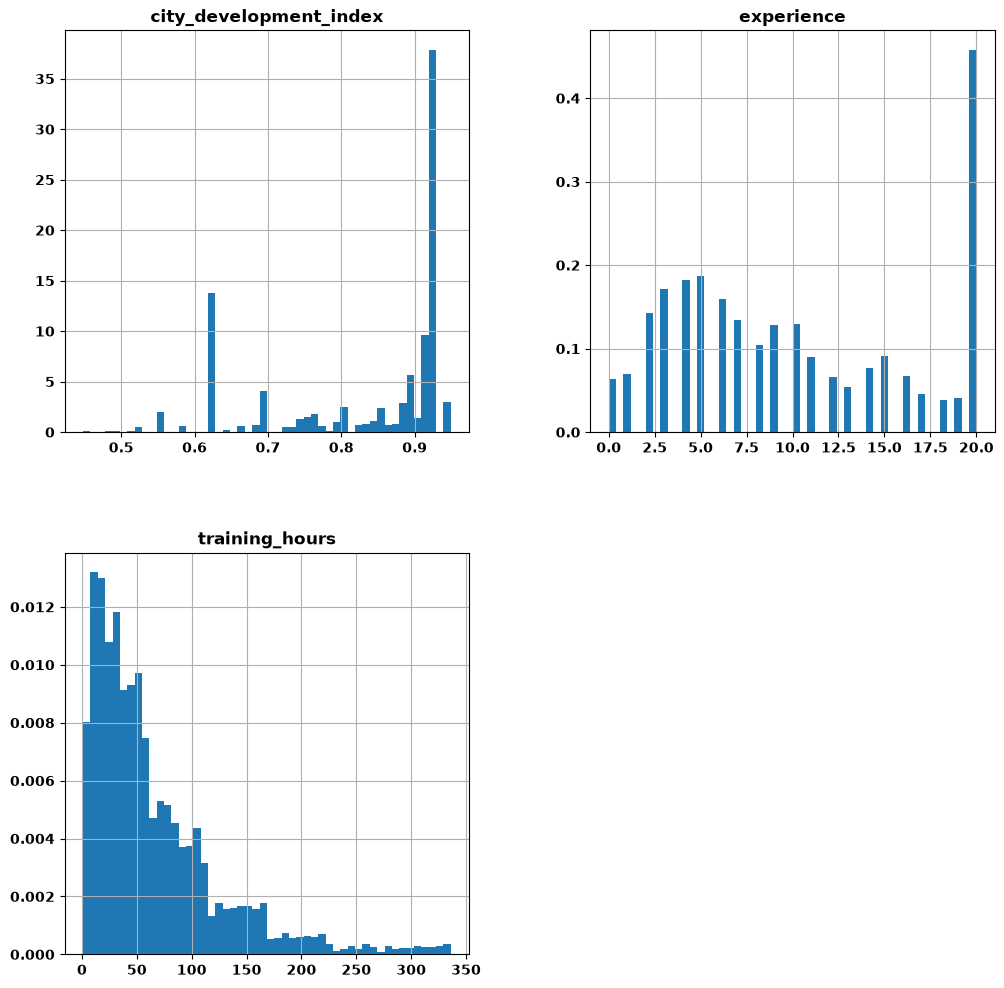

In [11]:
new_df.hist(bins=50, density=True, figsize=(12,12))
plt.show()

<Axes: >

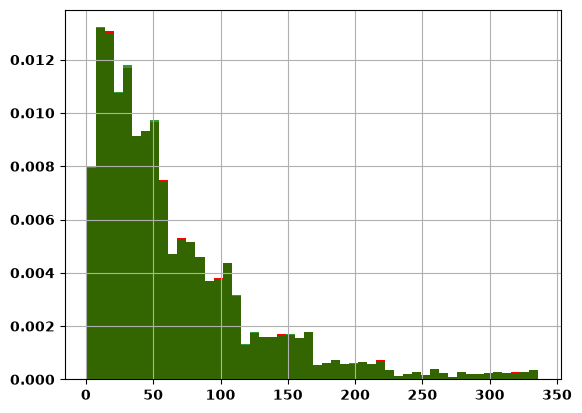

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

# orginal data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# data after CCA, the argument alpha makes the color transparent, so we can see the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.8)

<Axes: ylabel='Density'>

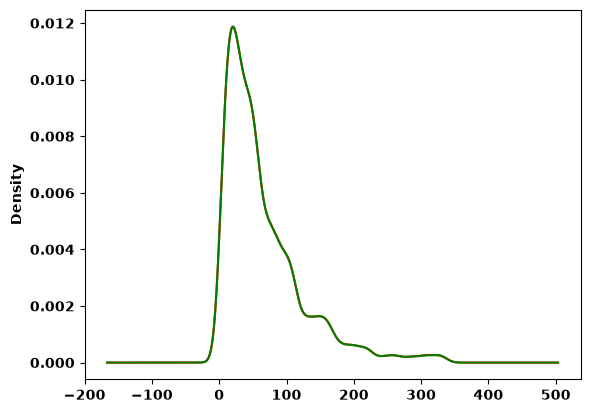

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

# orginal data
df['training_hours'].plot.density(color='red')

# data after CCA, 
new_df['training_hours'].plot.density(color='green')

<Axes: >

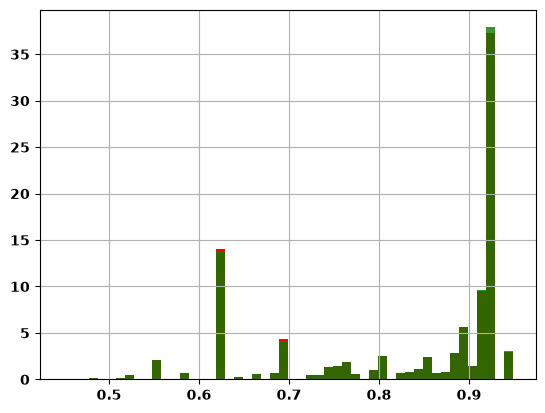

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

# orginal data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# data after CCA, the argument alpha makes the color transparent, so we can see the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.8)

<Axes: ylabel='Density'>

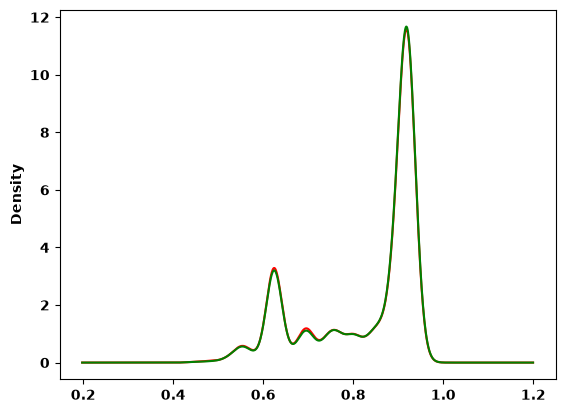

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

# orginal data
df['city_development_index'].plot.density(color='red')

# data after CCA, 
new_df['city_development_index'].plot.density(color='green')

<Axes: >

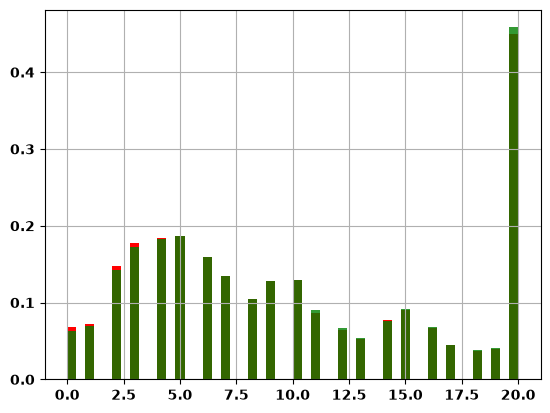

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# orginal data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after CCA, the argument alpha makes the color transparent, so we can see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.8)

<Axes: ylabel='Density'>

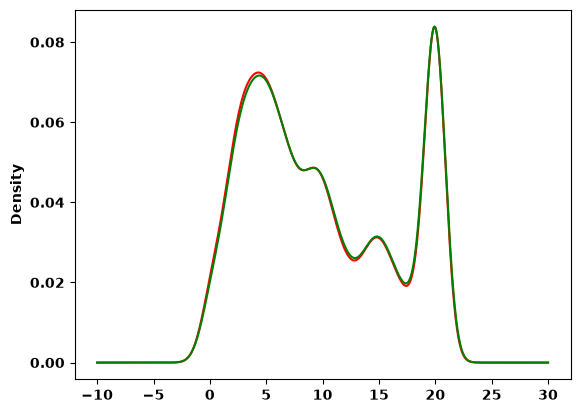

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)

# orginal data
df['experience'].plot.density(color='red')

# data after CCA, 
new_df['experience'].plot.density(color='green')

In [18]:
temp = pd.concat([
    # percentage of observations per category, original data
    df['enrolled_university'].value_counts() / len(df),

    # percentage of observation per category, cca data
    new_df['enrolled_university'].value_counts() / len(new_df)
],
axis=1)

# add column names

temp.columns = ['original', 'cca']

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [19]:
temp = pd.concat([
    # percentage of observations per category, original data
    df['education_level'].value_counts() / len(df),

    # percentage of observation per category, cca data
    new_df['education_level'].value_counts() / len(new_df)
],
axis=1)

# add column names

temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
